In [269]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [270]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [271]:
data = pd.read_csv('train_FD001.txt', header=None, delim_whitespace=True)
columns = ["unit_number","time_in_cycles",
           "setting1","setting2","setting3"] + \
          [f"sensor{i}" for i in range(1,22)]

data.columns = columns
data.to_csv('train_FD001.csv',index=False)


C:\Users\HP\AppData\Local\Temp\ipykernel_4000\1476254374.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv('train_FD001.txt', header=None, delim_whitespace=True)


In [272]:
data

,unit_number,time_in_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [273]:
data.head()

,unit_number,time_in_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [274]:
data.tail()

,unit_number,time_in_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,519.30,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522


In [275]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  int64  
 1   time_in_cycles  20631 non-null  int64  
 2   setting1        20631 non-null  float64
 3   setting2        20631 non-null  float64
 4   setting3        20631 non-null  float64
 5   sensor1         20631 non-null  float64
 6   sensor2         20631 non-null  float64
 7   sensor3         20631 non-null  float64
 8   sensor4         20631 non-null  float64
 9   sensor5         20631 non-null  float64
 10  sensor6         20631 non-null  float64
 11  sensor7         20631 non-null  float64
 12  sensor8         20631 non-null  float64
 13  sensor9         20631 non-null  float64
 14  sensor10        20631 non-null  float64
 15  sensor11        20631 non-null  float64
 16  sensor12        20631 non-null  float64
 17  sensor13        20631 non-null 

In [276]:
data.shape

(20631, 26)

In [277]:
data.describe()

,unit_number,time_in_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [278]:
data.isnull().sum().sum()

np.int64(0)

In [279]:
data.dropna(inplace=True)

In [280]:
data.duplicated().sum().sum()

np.int64(0)

In [281]:
for column in data.columns:
  print(column,":",data[column].nunique())
  if data[column].nunique() == 1:
    data.drop(column,axis=1,inplace=True)

unit_number : 100
time_in_cycles : 362
setting1 : 158
setting2 : 13
setting3 : 1
sensor1 : 1
sensor2 : 310
sensor3 : 3012
sensor4 : 4051
sensor5 : 1
sensor6 : 2
sensor7 : 513
sensor8 : 53
sensor9 : 6403
sensor10 : 1
sensor11 : 159
sensor12 : 427
sensor13 : 56
sensor14 : 6078
sensor15 : 1918
sensor16 : 1
sensor17 : 13
sensor18 : 1
sensor19 : 1
sensor20 : 120
sensor21 : 4745


In [282]:
data.shape

(20631, 19)

In [283]:
max_cycle = data.groupby("unit_number")["time_in_cycles"].max()
data["RUL"] = data["unit_number"].map(max_cycle) - data["time_in_cycles"]

In [284]:
data["RUL"] = data["RUL"].clip(upper=125)

In [285]:
window = 15

for col in data.columns:
    if col not in ["unit_number", "time_in_cycles", "RUL"]:
        data[col + "_mean"] = data.groupby("unit_number")[col].transform(lambda x: x.rolling(window).mean())
        data[col + "_std"] = data.groupby("unit_number")[col].transform(lambda x: x.rolling(window).std())


In [286]:
data.dropna(inplace=True)

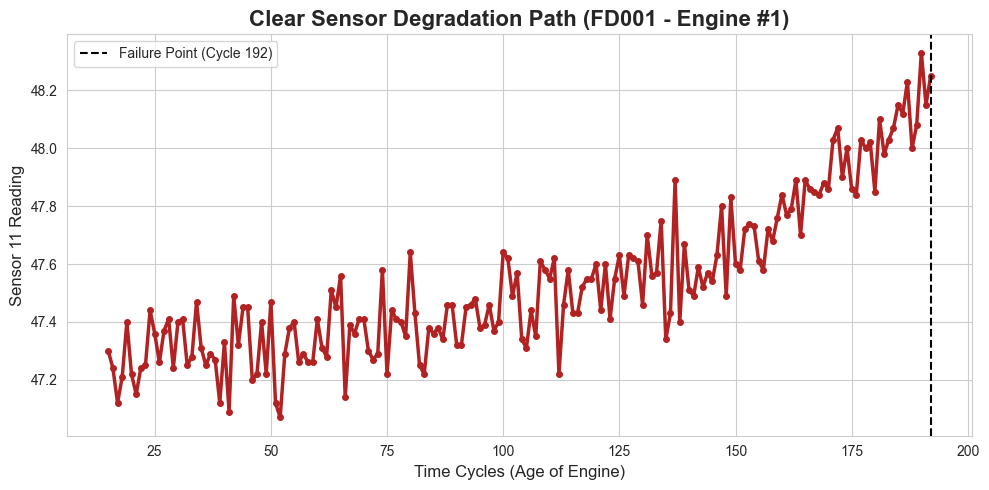

In [287]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))

engine_1_data = data[data['unit_number'] == 1]

plt.plot(engine_1_data['time_in_cycles'], engine_1_data['sensor11'], 
         color='firebrick', linewidth=2.5, marker='o', markersize=4)

plt.title("Clear Sensor Degradation Path (FD001 - Engine #1)", fontsize=16, fontweight='bold')
plt.xlabel("Time Cycles (Age of Engine)", fontsize=12)
plt.ylabel("Sensor 11 Reading", fontsize=12)

max_cycle = engine_1_data['time_in_cycles'].max()
plt.axvline(x=max_cycle, color='black', linestyle='--', label=f'Failure Point (Cycle {max_cycle})')

plt.legend()
plt.tight_layout()

plt.show()

In [288]:
data.drop(['unit_number','time_in_cycles','sensor6'],inplace=True,axis=1)

In [289]:
for column in data.columns:
  print(column,":",data[column].nunique())

setting1 : 157
setting2 : 13
sensor2 : 309
sensor3 : 2978
sensor4 : 4008
sensor7 : 511
sensor8 : 53
sensor9 : 6358
sensor11 : 157
sensor12 : 423
sensor13 : 56
sensor14 : 6047
sensor15 : 1901
sensor17 : 12
sensor20 : 119
sensor21 : 4667
RUL : 126
setting1_mean : 3229
setting1_std : 17846
setting2_mean : 795
setting2_std : 3509
sensor2_mean : 4218
sensor2_std : 19033
sensor3_mean : 14919
sensor3_std : 19212
sensor4_mean : 16525
sensor4_std : 19217
sensor6_mean : 11
sensor6_std : 118
sensor7_mean : 5734
sensor7_std : 19098
sensor8_mean : 903
sensor8_std : 17409
sensor9_mean : 17059
sensor9_std : 19222
sensor11_mean : 2775
sensor11_std : 18744
sensor12_mean : 5161
sensor12_std : 19070
sensor13_mean : 927
sensor13_std : 17421
sensor14_mean : 17329
sensor14_std : 19215
sensor15_mean : 12467
sensor15_std : 19208
sensor17_mean : 95
sensor17_std : 10947
sensor20_mean : 1852
sensor20_std : 18726
sensor21_mean : 16796
sensor21_std : 19223


In [290]:
data.corr()

,setting1,setting2,sensor2,sensor3,sensor4,sensor7,sensor8,sensor9,sensor11,sensor12,...,sensor14_mean,sensor14_std,sensor15_mean,sensor15_std,sensor17_mean,sensor17_std,sensor20_mean,sensor20_std,sensor21_mean,sensor21_std
setting1,1.000000,0.011816,0.011006,-0.006240,0.010788,-0.009836,0.000905,-0.003842,0.012852,-0.001968,...,-0.003878,-0.004554,0.006792,0.009660,0.007283,-0.000319,-0.006932,-0.008990,-0.009356,-0.009713
setting2,0.011816,1.000000,0.004577,0.006672,0.013113,-0.013049,0.008368,-0.004542,0.008417,-0.006286,...,-0.005470,0.008124,0.010367,-0.000608,0.005772,0.000987,-0.010610,0.011614,-0.008528,-0.013316
sensor2,0.011006,0.004577,1.000000,0.603884,0.716004,-0.703347,0.661451,0.273075,0.741450,-0.725637,...,0.164683,0.286905,0.784024,0.046237,0.776699,0.085756,-0.782787,0.068540,-0.783690,0.028895
sensor3,-0.006240,0.006672,0.603884,1.000000,0.678735,-0.664143,0.600750,0.322813,0.695947,-0.680455,...,0.225599,0.319736,0.739758,0.055014,0.738009,0.080901,-0.737965,0.067991,-0.739256,0.029925
sensor4,0.010788,0.013113,0.716004,0.678735,1.000000,-0.794274,0.745820,0.295481,0.831184,-0.816070,...,0.174178,0.311788,0.881287,0.062308,0.870648,0.087819,-0.879323,0.080376,-0.877640,0.032539
sensor7,-0.009836,-0.013049,-0.703347,-0.664143,-0.794274,1.000000,-0.766513,-0.214379,-0.823906,0.813085,...,-0.091551,-0.252424,-0.870308,-0.053400,-0.853315,-0.094977,0.869677,-0.074014,0.868667,-0.024833
sensor8,0.000905,0.008368,0.661451,0.600750,0.745820,-0.766513,1.000000,-0.039793,0.781226,-0.785901,...,-0.173643,0.108739,0.818734,0.048167,0.780481,0.081033,-0.817714,0.071680,-0.815833,0.007331
sensor9,-0.003842,-0.004542,0.273075,0.322813,0.295481,-0.214379,-0.039793,1.000000,0.271737,-0.206317,...,0.969574,0.724332,0.311176,0.042956,0.383313,0.062535,-0.305023,0.051966,-0.314775,0.061129
sensor11,0.012852,0.008417,0.741450,0.695947,0.831184,-0.823906,0.781226,0.271737,1.000000,-0.847254,...,0.145139,0.301100,0.909877,0.061012,0.895837,0.091486,-0.907697,0.076834,-0.907730,0.024483
sensor12,-0.001968,-0.006286,-0.725637,-0.680455,-0.816070,0.813085,-0.785901,-0.206317,-0.847254,1.000000,...,-0.078461,-0.249135,-0.893035,-0.056577,-0.873736,-0.091881,0.890873,-0.075887,0.890579,-0.028980


<Axes: >

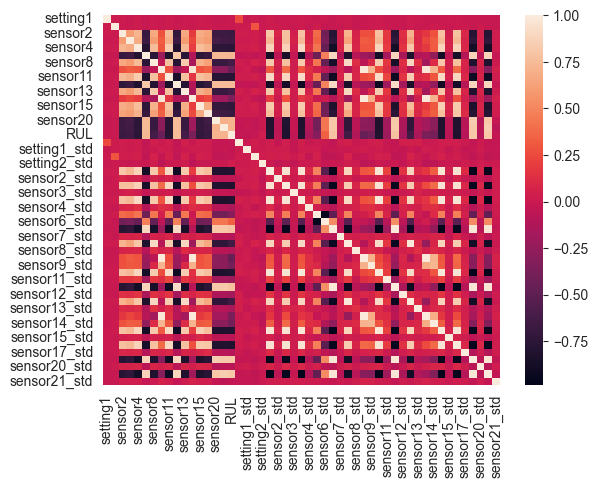

In [291]:
sns.heatmap(data.corr(),annot=False)

In [292]:
data.corr()['RUL']

setting1        -0.007349
setting2        -0.005949
sensor2         -0.681621
sensor3         -0.655512
sensor4         -0.758706
sensor7          0.735598
sensor8         -0.626943
sensor9         -0.453399
sensor11        -0.777565
sensor12         0.751343
sensor13        -0.625488
sensor14        -0.362315
sensor15        -0.723355
sensor17        -0.683608
sensor20         0.706163
sensor21         0.709378
RUL              1.000000
setting1_mean   -0.030575
setting1_std    -0.033149
setting2_mean   -0.027413
setting2_std     0.033303
sensor2_mean    -0.805122
sensor2_std     -0.053872
sensor3_mean    -0.814191
sensor3_std     -0.044504
sensor4_mean    -0.808661
sensor4_std     -0.144450
sensor6_mean    -0.307142
sensor6_std      0.334332
sensor7_mean     0.785688
sensor7_std     -0.106160
sensor8_mean    -0.644030
sensor8_std     -0.110980
sensor9_mean    -0.455748
sensor9_std     -0.387705
sensor11_mean   -0.802248
sensor11_std    -0.215278
sensor12_mean    0.782747
sensor12_std

In [293]:
corr = data.corr()["RUL"].abs().sort_values(ascending=False)
print(corr.head(20))

RUL              1.000000
sensor17_mean    0.818218
sensor3_mean     0.814191
sensor15_mean    0.811757
sensor4_mean     0.808661
sensor21_mean    0.807265
sensor20_mean    0.807078
sensor2_mean     0.805122
sensor11_mean    0.802248
sensor7_mean     0.785688
sensor12_mean    0.782747
sensor11         0.777565
sensor4          0.758706
sensor12         0.751343
sensor7          0.735598
sensor15         0.723355
sensor21         0.709378
sensor20         0.706163
sensor17         0.683608
sensor2          0.681621
Name: RUL, dtype: float64


In [294]:
data.shape

(19231, 51)

In [295]:
features = ['sensor17_mean','sensor3_mean','sensor15_mean','sensor21_mean','sensor4_mean','sensor20_mean','sensor2_mean','sensor11_mean','sensor7_mean','sensor12_mean','sensor11','sensor4','sensor12','sensor7','sensor15','sensor21','sensor20','sensor17','sensor2']

In [296]:
len(features)

19

In [297]:
from scipy.stats import shapiro
for column in features:
  stat, p = shapiro(data[column].sample(5000, random_state=42))

  print(p)

5.278297593990355e-30
5.010396431929646e-29
1.0331855623909481e-29
7.684268585619882e-28
1.2222236488557174e-29
1.684655821105802e-27
2.505118906453658e-27
4.494933799447619e-28
2.3388009248453884e-27
1.78470239992502e-27
1.8034897405291542e-24
6.877889025096459e-22
1.3229500335818677e-22
3.449668043738316e-19
3.3935909551759827e-19
9.693574865383119e-17
6.961286407153717e-16
1.3387681961305366e-36
5.4767072419830136e-15


In [298]:
#sns.pairplot(data=data)

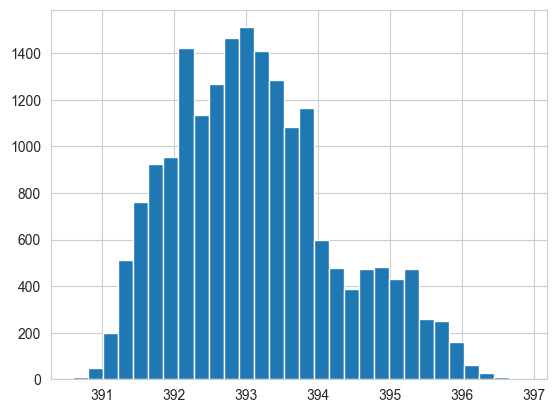

In [299]:
plt.hist(data["sensor17_mean"], bins=30)
plt.show()

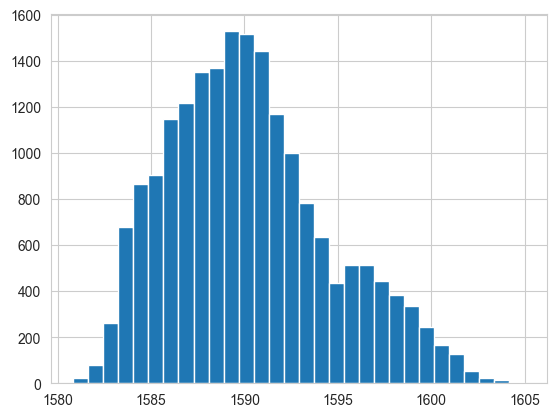

In [300]:
plt.hist(data["sensor3_mean"], bins=30)
plt.show()

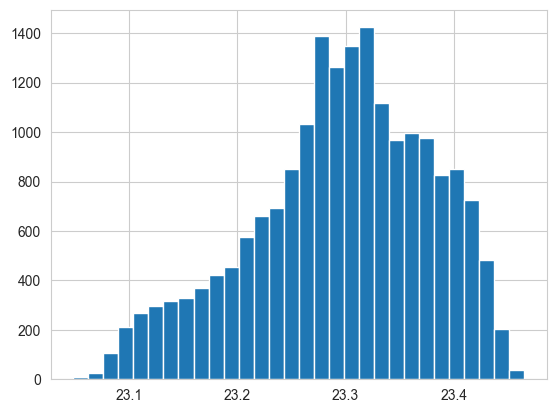

In [301]:
plt.hist(data["sensor21_mean"], bins=30)
plt.show()

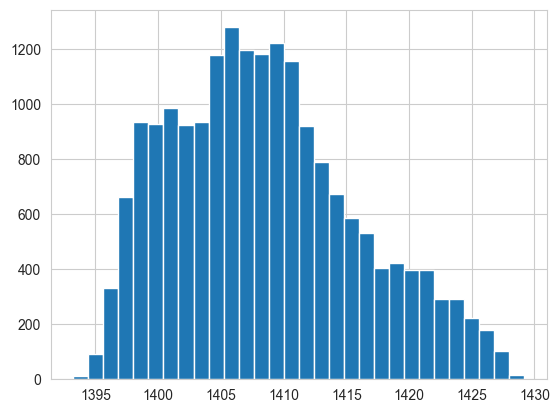

In [302]:
plt.hist(data["sensor4_mean"], bins=30)
plt.show()

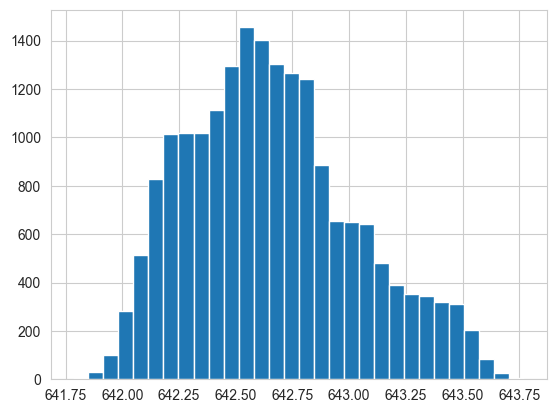

In [303]:
plt.hist(data["sensor2_mean"], bins=30)
plt.show()

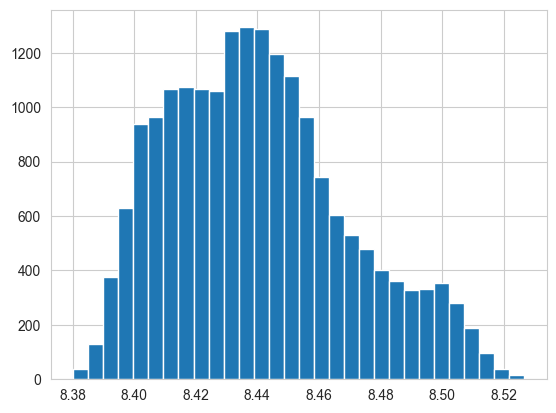

In [304]:
plt.hist(data["sensor15_mean"], bins=30)
plt.show()

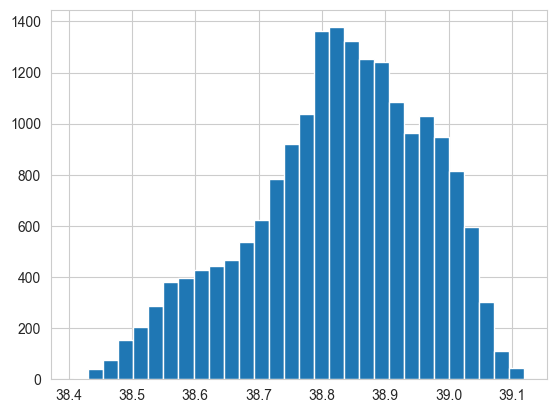

In [305]:
plt.hist(data["sensor20_mean"], bins=30)
plt.show()

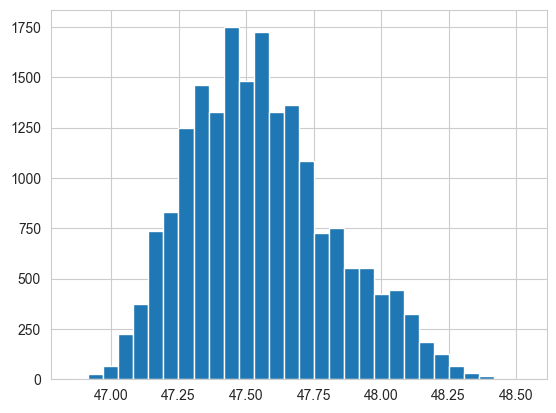

In [306]:
plt.hist(data["sensor11"], bins=30)
plt.show()

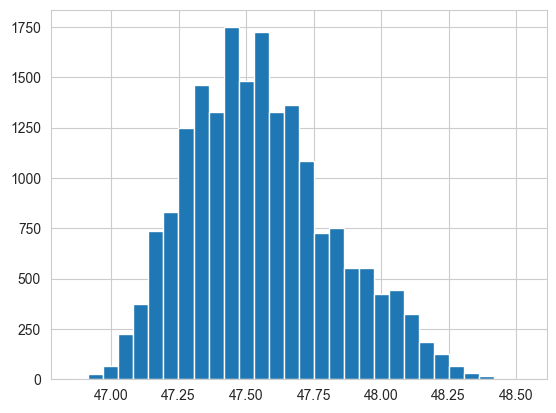

In [307]:
plt.hist(data["sensor11"], bins=30)
plt.show()

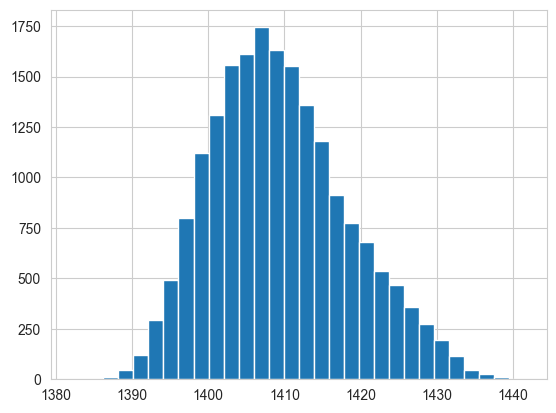

In [308]:
plt.hist(data["sensor4"], bins=30)
plt.show()

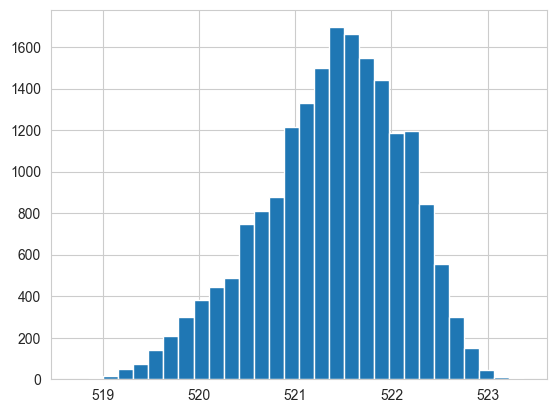

In [309]:
plt.hist(data["sensor12"], bins=30)
plt.show()

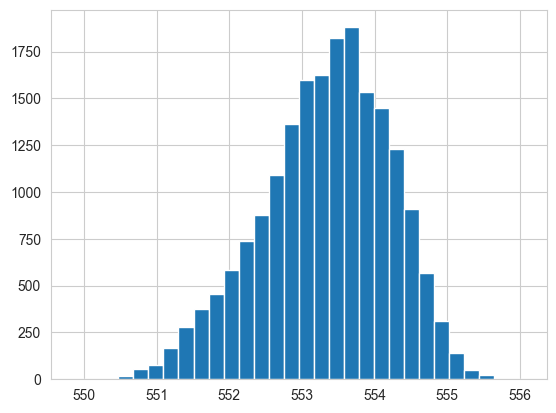

In [310]:
plt.hist(data["sensor7"], bins=30)
plt.show()

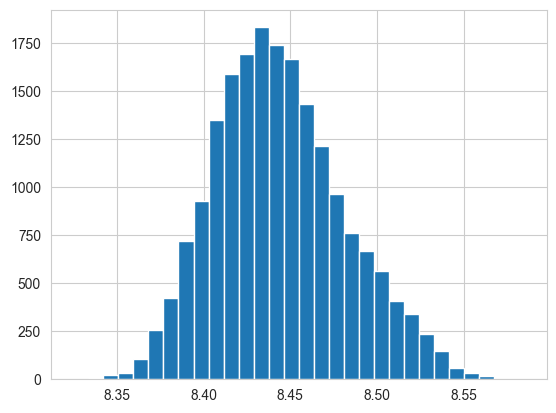

In [311]:
plt.hist(data["sensor15"], bins=30)
plt.show()

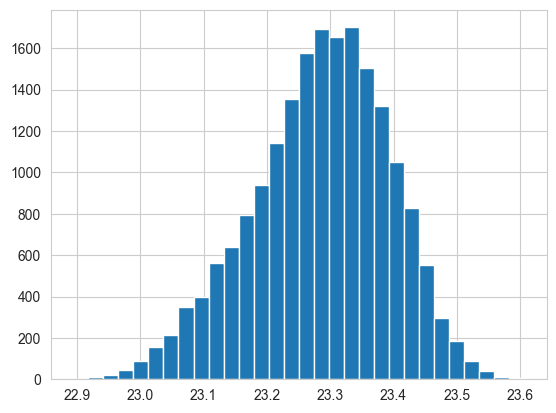

In [312]:
plt.hist(data["sensor21"], bins=30)
plt.show()

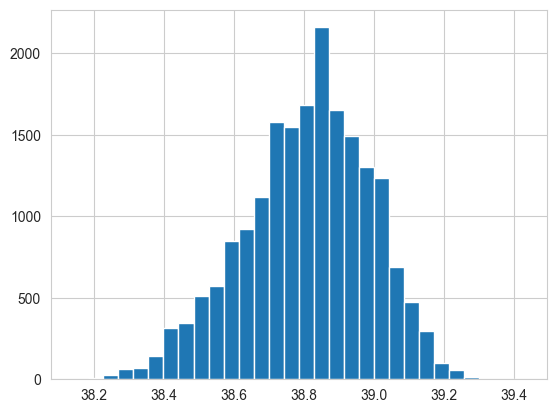

In [313]:
plt.hist(data["sensor20"], bins=30)
plt.show()

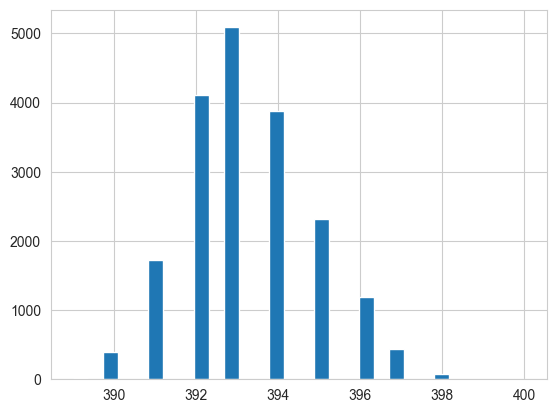

In [314]:
plt.hist(data["sensor17"], bins=30)
plt.show()

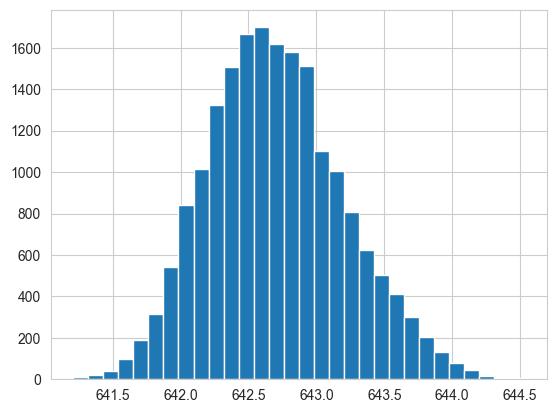

In [315]:
plt.hist(data["sensor2"], bins=30)
plt.show()

In [316]:
# Outliers
for column in features:
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outliers = data[(data[column] < lower) | (data[column] > upper)]
  print(column)
  print("number Outliers:", len(outliers))
  print("percentage Outliers:", len(outliers)/len(data)*100, "%")
  print("******************************************")

sensor17_mean
number Outliers: 75
percentage Outliers: 0.38999532005615933 %
******************************************
sensor3_mean
number Outliers: 145
percentage Outliers: 0.7539909521085747 %
******************************************
sensor15_mean
number Outliers: 32
percentage Outliers: 0.1663980032239613 %
******************************************
sensor21_mean
number Outliers: 31
percentage Outliers: 0.1611980656232125 %
******************************************
sensor4_mean
number Outliers: 1
percentage Outliers: 0.005199937600748791 %
******************************************
sensor20_mean
number Outliers: 41
percentage Outliers: 0.21319744163070045 %
******************************************
sensor2_mean
number Outliers: 44
percentage Outliers: 0.2287972544329468 %
******************************************
sensor11_mean
number Outliers: 6
percentage Outliers: 0.03119962560449275 %
******************************************
sensor7_mean
number Outliers: 37
percentage Out

In [317]:
x = data[features]
y = data['RUL']

In [318]:
x.shape

(19231, 19)

In [319]:
x

,sensor17_mean,sensor3_mean,sensor15_mean,sensor21_mean,sensor4_mean,sensor20_mean,sensor2_mean,sensor11_mean,sensor7_mean,sensor12_mean,sensor11,sensor4,sensor12,sensor7,sensor15,sensor21,sensor20,sensor17,sensor2
14,391.866667,1586.749333,8.409547,23.383267,1400.754000,38.996000,642.280000,47.278000,554.105333,522.045333,47.30,1402.13,522.50,553.64,8.4199,23.3500,38.99,391,642.43
15,391.866667,1586.634667,8.407820,23.385667,1401.014000,38.990000,642.300667,47.262667,554.077333,522.034000,47.24,1404.50,521.49,553.94,8.3936,23.4550,38.97,392,642.13
16,391.866667,1586.177333,8.409313,23.379553,1400.801333,38.977333,642.329333,47.238000,554.080667,522.008000,47.12,1399.95,521.89,553.80,8.4542,23.3319,38.81,392,642.58
17,392.000000,1586.380667,8.408313,23.383187,1400.262667,38.973333,642.347333,47.234000,554.076667,521.964000,47.21,1396.12,521.76,554.20,8.4028,23.3987,38.89,392,642.62
18,391.933333,1586.698667,8.412573,23.381353,1400.161333,38.968000,642.310000,47.252000,554.058667,521.899333,47.40,1400.35,521.89,554.18,8.4321,23.3464,38.80,391,641.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,395.733333,1599.226667,8.502800,23.105207,1424.822667,38.465333,643.459333,48.046667,551.599333,520.034000,48.07,1428.63,519.49,551.43,8.4956,22.9735,38.49,397,643.49
20627,395.666667,1599.239333,8.504693,23.107240,1425.879333,38.458000,643.460667,48.066000,551.558667,520.009333,48.04,1433.58,519.68,550.86,8.5139,23.1594,38.30,395,643.54
20628,395.866667,1599.763333,8.508960,23.098067,1425.940000,38.454667,643.466000,48.072000,551.499333,519.967333,48.09,1428.18,520.01,550.94,8.5646,22.9333,38.44,398,643.42
20629,395.800000,1600.188667,8.511627,23.094140,1426.316000,38.444667,643.487333,48.099333,551.430000,519.942000,48.39,1426.53,519.67,550.68,8.5389,23.0640,38.29,395,643.23


In [320]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=.2)

In [321]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [322]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [323]:
model = RandomForestRegressor(
    n_estimators=800,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

model.fit(x_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",800
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [324]:
y_pred_randomforest = model.predict(x_test)

In [325]:
rmse = mean_squared_error(y_test, y_pred_randomforest) ** 0.5
r2 = r2_score(y_test, y_pred_randomforest)

print("RMSE:", rmse)
print("R2 Score:", r2)
print("MAE:", mean_absolute_error(y_test, y_pred_randomforest))
print("Train", model.score(x_train, y_train))
print("Test", model.score(x_test, y_test))

RMSE: 17.859951987683488
R2 Score: 0.8190663565420608
MAE: 13.335439936985026
Train 0.9376593251924316
Test 0.8190663565420608


In [326]:
import pandas as pd

importance = model.feature_importances_
feat_importance = pd.Series(importance, index=x.columns)
print(feat_importance.sort_values(ascending=False))


sensor3_mean     0.536085
sensor4_mean     0.138943
sensor17_mean    0.082345
sensor2_mean     0.050273
sensor15_mean    0.029901
sensor7_mean     0.022108
sensor20_mean    0.021697
sensor12_mean    0.020837
sensor11_mean    0.019886
sensor21_mean    0.015053
sensor4          0.009652
sensor15         0.008486
sensor12         0.007858
sensor7          0.007619
sensor11         0.007299
sensor21         0.007174
sensor2          0.006804
sensor20         0.005748
sensor17         0.002230
dtype: float64


In [327]:
x = data.drop('RUL', axis=1)

important_features = feat_importance[feat_importance > 0.005].index

x = x[important_features]
print(important_features)
print(len(important_features))

Index(['sensor17_mean', 'sensor3_mean', 'sensor15_mean', 'sensor21_mean',
       'sensor4_mean', 'sensor20_mean', 'sensor2_mean', 'sensor11_mean',
       'sensor7_mean', 'sensor12_mean', 'sensor11', 'sensor4', 'sensor12',
       'sensor7', 'sensor15', 'sensor21', 'sensor20', 'sensor2'],
      dtype='object')
18


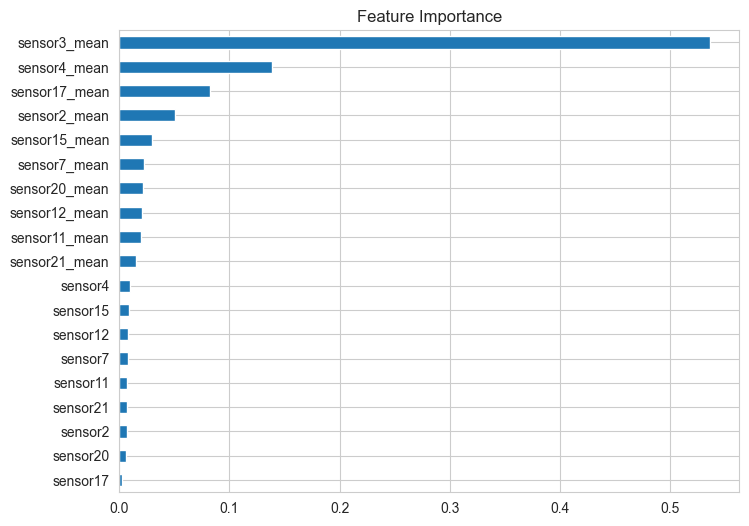

In [328]:
import matplotlib.pyplot as plt

feat_importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()


In [329]:
import joblib as jp
jp.dump(model,'model.pkl')
jp.dump(scaler,'scaler.pkl')
jp.dump(features,'features.pkl')

['features.pkl']

In [330]:
test = pd.read_csv('test_FD001.txt', header=None, delim_whitespace=True)
test.to_csv('test_FD001.csv',index=False)
columns = ["unit_number","time_in_cycles",
           "setting1","setting2","setting3"] + \
          [f"sensor{i}" for i in range(1,22)]

test.columns = columns

C:\Users\HP\AppData\Local\Temp\ipykernel_4000\3310737453.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  test = pd.read_csv('test_FD001.txt', header=None, delim_whitespace=True)


In [331]:
test

,unit_number,time_in_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100,194,0.0049,0.0000,100.0,518.67,643.24,1599.45,1415.79,14.62,...,520.69,2388.00,8213.28,8.4715,0.03,394,2388,100.0,38.65,23.1974
13092,100,195,-0.0011,-0.0001,100.0,518.67,643.22,1595.69,1422.05,14.62,...,521.05,2388.09,8210.85,8.4512,0.03,395,2388,100.0,38.57,23.2771
13093,100,196,-0.0006,-0.0003,100.0,518.67,643.44,1593.15,1406.82,14.62,...,521.18,2388.04,8217.24,8.4569,0.03,395,2388,100.0,38.62,23.2051
13094,100,197,-0.0038,0.0001,100.0,518.67,643.26,1594.99,1419.36,14.62,...,521.33,2388.08,8220.48,8.4711,0.03,395,2388,100.0,38.66,23.2699


In [332]:
rul = pd.read_csv('RUL_FD001.txt', header=None, delim_whitespace=True)
rul.to_csv('RUL_FD001.csv',index=False)
rul.columns = ['RUL']

C:\Users\HP\AppData\Local\Temp\ipykernel_4000\514575648.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  rul = pd.read_csv('RUL_FD001.txt', header=None, delim_whitespace=True)


In [333]:
rul

,RUL
0,112
1,98
2,69
3,82
4,91
...,...
95,137
96,82
97,59
98,117


In [334]:
test.isna().sum().sum()

np.int64(0)

In [335]:
test.duplicated().sum().sum()

np.int64(0)

In [336]:
for column in test.columns:
  print(column,":",test[column].nunique())
  if test[column].nunique() == 1:
    test.drop(column,axis=1,inplace=True)

unit_number : 100
time_in_cycles : 303
setting1 : 150
setting2 : 14
setting3 : 1
sensor1 : 1
sensor2 : 262
sensor3 : 2361
sensor4 : 2954
sensor5 : 1
sensor6 : 2
sensor7 : 415
sensor8 : 41
sensor9 : 4047
sensor10 : 1
sensor11 : 136
sensor12 : 357
sensor13 : 43
sensor14 : 3786
sensor15 : 1506
sensor16 : 1
sensor17 : 9
sensor18 : 1
sensor19 : 1
sensor20 : 103
sensor21 : 3555


In [337]:
window = 15

for col in test.columns:
    if col not in ["unit_number", "time_in_cycles", "RUL"]:
        test[col + "_mean"] = test.groupby("unit_number")[col].transform(lambda x: x.rolling(window).mean())
        test[col + "_std"] = test.groupby("unit_number")[col].transform(lambda x: x.rolling(window).std())

In [338]:
test = test.dropna()

In [339]:
test.duplicated().sum().sum()

np.int64(0)

In [340]:
scaler = jp.load('scaler.pkl')
model = jp.load('model.pkl')
features = jp.load('features.pkl')

In [341]:
x_test_final = test[features]

In [342]:
x_test_final = scaler.transform(x_test_final)

In [343]:
last_cycles = test.groupby("unit_number").tail(1)
X_test_final = last_cycles[features]
X_test_final = scaler.transform(X_test_final)
y_pred_test = model.predict(X_test_final)


In [344]:
test.drop(['unit_number','time_in_cycles'],inplace=True,axis=1)

C:\Users\HP\AppData\Local\Temp\ipykernel_4000\2065978938.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.drop(['unit_number','time_in_cycles'],inplace=True,axis=1)


In [345]:
mse = mean_absolute_error(rul,y_pred_test)
print("MSE",mse)

MSE 16.05930589390035


In [346]:
mse = mean_squared_error(rul, y_pred_test)
rmse = np.sqrt(mse)
r2score = r2_score(rul, y_pred_test)
mae = mean_absolute_error(rul, y_pred_test)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2score)



MSE: 473.72308655865925
RMSE: 21.765180600184767
MAE: 16.05930589390035
R2 Score: 0.7256752411654828


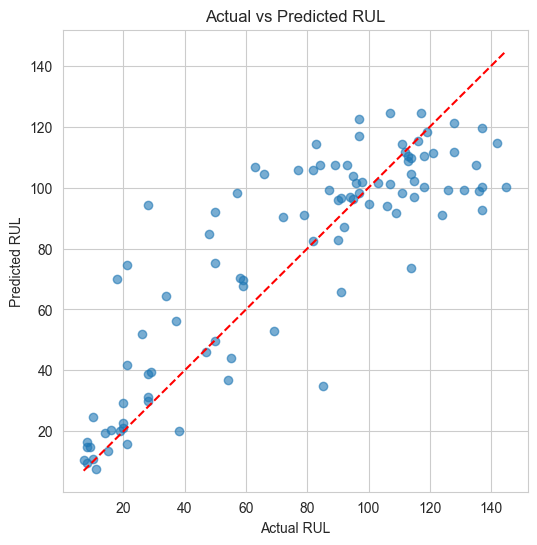

In [347]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(rul, y_pred_test, alpha=0.6)

plt.plot([rul.min(), rul.max()],
         [rul.min(), rul.max()],
         'r--')

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()


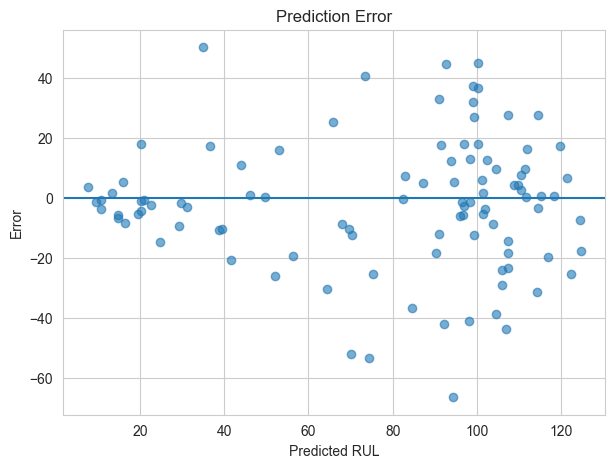

In [348]:
error = rul.iloc[:,0] - y_pred_test


plt.figure(figsize=(7,5))
plt.scatter(y_pred_test, error, alpha=0.6)

plt.axhline(0)

plt.xlabel("Predicted RUL")
plt.ylabel("Error")
plt.title("Prediction Error")

plt.show()


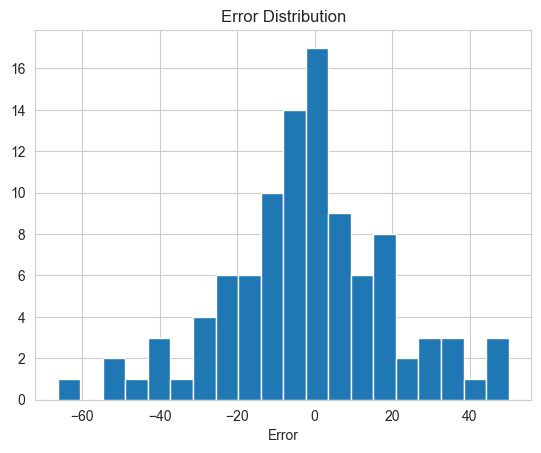

In [349]:
plt.hist(error, bins=20)

plt.xlabel("Error")
plt.title("Error Distribution")

plt.show()


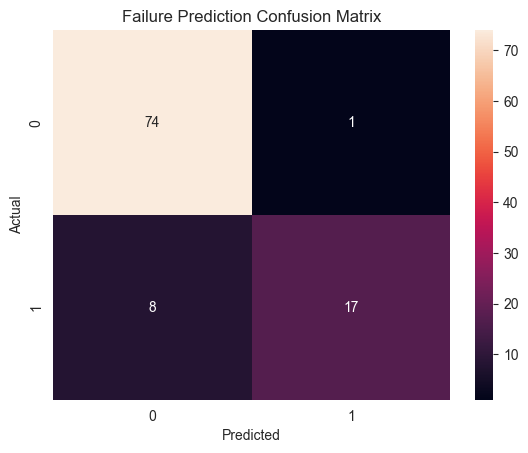

In [350]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = np.where(rul.iloc[:,0] <= 30, 1, 0)
y_pred = np.where(y_pred_test <= 30, 1, 0)

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Failure Prediction Confusion Matrix")

plt.show()


In [351]:
jp.dump(model,'model.pkl')


['model.pkl']